# SNAP

In [ ]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from matplotlib.colors import ListedColormap
from natsort import natsorted

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set IO path
base_path = '/home/jiahao/wanglab/Data/Analyzed/2024-12-02-Mingrui-SCZ/'
expr_path = os.path.join(base_path, 'expr')
fig_path = os.path.join(base_path, 'figures')
output_path = os.path.join(base_path, 'output')
os.makedirs(output_path, exist_ok=True)

sc.settings.figdir = fig_path
input_path = os.path.join(expr_path, 'DE analysis')

## Input

In [4]:
# adata
adata = sc.read_h5ad(os.path.join(expr_path, '2025-04-11-finalized-ct-rgn.h5ad'))
adata

AnnData object with n_obs × n_vars = 538188 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label'
    var: 'highly_variable', 'mean', 'std', 'max_counts'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'level_3_color_dict', 'level_3_colors', 'level_3_order', 'region_label_color_dict', 'region_label_order'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial'
    varm: 'PCs'
  

### Gene list

In [5]:
# load snap gene list
snap_n_gene_df = pd.read_excel(os.path.join(base_path, "documents", 'SNAP-n.xlsx'), sheet_name='Gene loadings')
snap_a_gene_df = pd.read_excel(os.path.join(base_path, "documents", 'SNAP-a.xlsx'), sheet_name='Gene loadings')

In [6]:
adata.var['SNAP-n'] = adata.var_names.str.upper().isin(snap_n_gene_df['Gene'])
adata.var['SNAP-n_loading'] = adata.var_names.str.upper().map(snap_n_gene_df.set_index('Gene')['SNAP-n'])

adata.var['SNAP-a'] = adata.var_names.str.upper().isin(snap_a_gene_df['Gene'])
adata.var['SNAP-a_loading'] = adata.var_names.str.upper().map(snap_a_gene_df.set_index('Gene')['SNAP-a'])

In [7]:
adata.var['SNAP-n'].values.sum(), adata.var['SNAP-a'].values.sum()

(np.int64(3245), np.int64(3252))

Text(0.5, 0, 'Gene loadings')

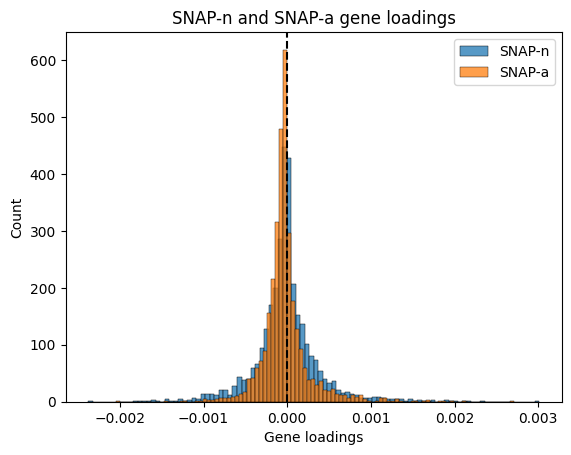

In [8]:
sns.histplot(adata.var['SNAP-n_loading'], bins=100)
sns.histplot(adata.var['SNAP-a_loading'], bins=100)
# add legend
plt.legend(['SNAP-n', 'SNAP-a'])
plt.axvline(0, color='k', linestyle='--')
plt.title('SNAP-n and SNAP-a gene loadings')
plt.xlabel('Gene loadings')

In [9]:
top_snap_a_genes = adata.var['SNAP-a_loading'].sort_values(ascending=False).head(1000).index
top_snap_n_genes = adata.var['SNAP-n_loading'].sort_values(ascending=False).head(1000).index

all_snap_a_genes = adata.var.index[adata.var['SNAP-a']].tolist()
all_snap_n_genes = adata.var.index[adata.var['SNAP-n']].tolist()

In [10]:
# Load all sheets from the Excel file into a dictionary
l3_deg_combined_file_path = os.path.join(input_path, '2025-04-09_level_3_combined_DEG.xlsx')
excel_data = pd.ExcelFile(l3_deg_combined_file_path)

# Create a dictionary where keys are sheet names and values are DataFrames
l3_deg_combined_dict = {sheet_name: excel_data.parse(sheet_name) for sheet_name in excel_data.sheet_names}

In [12]:
log_fc = 0.2
pvals_adj = 0.05
ctype_list = ['AC_1', 'AC_2', 'AC_3',
              'TEGLU_L2_3', 'TEGLU_L4_5', 'TEGLU_L5_6', 'TEGLU_L6', 'TEGLU_CA', 'DGGRC',
              'DEGLU', 'MSN_1', 'MSN_2', 'HABCHO', 'PEP',
              'TEINH_1', 'TEINH_2', 'TEINH_3', 'TEINH_4']

deg_df_list = []
for ctype in ctype_list:

    current_dict = l3_deg_combined_dict
    current_ribo_key = f"{ctype}_RIBO".replace('/', '_')
    current_star_key = f"{ctype}_STAR".replace('/', '_')

    current_ribo_deg = current_dict[current_ribo_key]
    current_ribo_deg['logfoldchanges_abs'] = current_ribo_deg['logfoldchanges'].abs()
    current_ribo_deg = current_ribo_deg.loc[(current_ribo_deg.logfoldchanges_abs > log_fc) & (current_ribo_deg.pvals_adj < pvals_adj), :]

    current_star_deg = current_dict[current_star_key]
    current_star_deg['logfoldchanges_abs'] = current_star_deg['logfoldchanges'].abs()
    current_star_deg = current_star_deg.loc[(current_star_deg.logfoldchanges_abs > log_fc) & (current_star_deg.pvals_adj < pvals_adj), :]

    current_ribo_deg['source'] = 'RIBO'
    current_star_deg['source'] = 'STAR'
    current_combined_df = pd.concat([current_ribo_deg, current_star_deg], axis=0)
    current_combined_df['ctype'] = ctype
    deg_df_list.append(current_combined_df)

combined_df = pd.concat(deg_df_list, axis=0)
combined_df


,names,scores,logfoldchanges,pvals,pvals_adj,scores_rep1,logfoldchanges_rep1,pvals_rep1,pvals_adj_rep1,scores_rep2,logfoldchanges_rep2,pvals_rep2,pvals_adj_rep2,logfoldchanges_abs,source,ctype
0,Slc6a1,3.992557,0.287115,6.536473e-05,1.733171e-02,2.382006,0.202185,1.721860e-02,1.000000,3.050016,0.362444,2.288289e-03,1.000000,0.287115,RIBO,AC_1
1,Sema3g,3.763547,0.323786,1.675202e-04,4.124587e-02,1.866572,0.222942,6.196137e-02,1.000000,3.202050,0.401392,1.364531e-03,1.000000,0.323786,RIBO,AC_1
3435,Cbx5,-4.128001,-0.754851,3.659310e-05,1.051137e-02,-3.300426,-0.857839,9.653828e-04,0.184702,-2.547391,-0.657178,1.085316e-02,1.000000,0.754851,RIBO,AC_1
3436,Htra1,-4.137286,-0.784007,3.514376e-05,1.051137e-02,-4.812851,-1.248044,1.487920e-06,0.000513,-0.882543,-0.251398,3.774833e-01,1.000000,0.784007,RIBO,AC_1
3437,Ppp1r9b,-4.285332,-0.486862,1.824664e-05,6.289617e-03,-3.532761,-0.538305,4.112439e-04,0.088597,-2.764312,-0.465506,5.704299e-03,1.000000,0.486862,RIBO,AC_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3442,Ppp3ca,-5.970023,-1.536699,2.372197e-09,1.635393e-06,-3.878455,-1.580611,1.051221e-04,0.051765,-4.686009,-1.555944,2.785841e-06,0.001600,1.536699,RIBO,TEINH_4
3443,Nrgn,-6.179217,-0.993906,6.442043e-10,5.551430e-07,-3.322884,-0.768042,8.909194e-04,0.307100,-5.642158,-1.248077,1.679319e-08,0.000019,0.993906,RIBO,TEINH_4
3444,Gad2,-6.769862,-1.780116,1.289050e-11,1.481119e-08,-4.530225,-1.906308,5.892085e-06,0.003385,-5.216665,-1.739824,1.821733e-07,0.000126,1.780116,RIBO,TEINH_4
3445,Camk2a,-7.296751,-1.077250,2.948007e-13,5.080890e-10,-4.931108,-0.988838,8.176430e-07,0.000564,-5.645510,-1.194702,1.646928e-08,0.000019,1.077250,RIBO,TEINH_4


In [13]:
combined_df_subset = combined_df.loc[combined_df['source'] == 'RIBO', :].copy()
# combined_df_subset = combined_df.copy()
ac_up_list = list(set(combined_df_subset.loc[(combined_df_subset['ctype'].str.contains('AC_')) & (combined_df_subset.logfoldchanges > 0), 'names'].tolist()))
ac_down_list = list(set(combined_df_subset.loc[(combined_df_subset['ctype'].str.contains('AC_')) & (combined_df_subset.logfoldchanges < 0), 'names'].tolist()))
ac_list = list(set(ac_up_list) | set(ac_down_list))

neuron_up_list = list(set(combined_df_subset.loc[(~combined_df_subset['ctype'].str.contains('AC_')) & (combined_df_subset.logfoldchanges > 0), 'names'].tolist()))
neuron_down_list = list(set(combined_df_subset.loc[(~combined_df_subset['ctype'].str.contains('AC_')) & (combined_df_subset.logfoldchanges < 0), 'names'].tolist()))
neuron_list = list(set(neuron_up_list) | set(neuron_down_list))

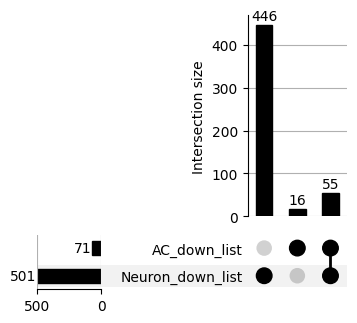

In [14]:

gene_lists = {
    'AC_down_list': ac_list,
    'Neuron_down_list': neuron_list,
    # 'Top_SNAP-a_list': top_snap_a_genes,
    # 'Top_SNAP-n_list': top_snap_n_genes,
}

from upsetplot import from_contents, plot
gene_list_upset = from_contents(gene_lists)
plot(gene_list_upset, show_counts=True)
plt.show()

In [ ]:
gene_lists = {}
combined_df_subset = combined_df.loc[combined_df['source'] == 'RIBO', :].copy()

for ctype in ctype_list:
    gene_lists[ctype] = list(set(combined_df_subset.loc[(combined_df_subset['ctype'] == ctype) & (combined_df_subset.logfoldchanges < 0), 'names'].tolist()))

from upsetplot import from_contents, plot
gene_list_upset = from_contents(gene_lists)
plot(gene_list_upset, show_counts=True)
plt.show()

In [ ]:
# gene_list_upset.loc[(True, False, False, False), :]
gene_list_upset.loc[(False, True, False, False), 'id'].values

## Color

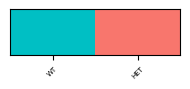

In [11]:
# WT, HET
condition_order = ['WT', 'HET']
condition_pl = sns.color_palette(['#00bfc4', '#f8766d'])
condition_cmap = ListedColormap(condition_pl.as_hex())
sns.palplot(condition_pl)
plt.xticks(range(len(condition_order)), condition_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

In [12]:
# export as editable fonts
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

## Bulk comparison

In [24]:
# subset adata with AC and top 10% of SNAP-a
sdata = adata[(adata.obs['level_2'] == 'AC') & (adata.obs['protocol'] == 'STAR'), top_snap_a_genes]
# sdata = adata[(adata.obs['level_3'].isin(['TEGLU_L2/3-[Lamp5_Cux2]', 'TEGLU_L4/5-[Rorb_Plcxd2]', 'TEGLU_L5/6-[C1ql3_Tox]', 
#                                           'TEGLU_L6-[Pcp4_Hs3st4]'])) & (adata.obs['protocol'] == 'STAR'), top_snap_n_genes]
sdata

View of AnnData object with n_obs × n_vars = 28242 × 1000
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label'
    var: 'highly_variable', 'mean', 'std', 'max_counts', 'SNAP-n', 'SNAP-n_loading', 'SNAP-a', 'SNAP-a_loading'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'level_3_color_dict', 'level_3_colors', 'level_3_order', 'region_label_color_dict', 'region_label_order'
    obsm: '

In [25]:
# get gene expression profile under two conditions
expr = pd.DataFrame(sdata.layers['log2_norm1e4'].toarray(), index=sdata.obs_names, columns=sdata.var_names)
expr['condition'] = sdata.obs['condition']
plot_df = expr.groupby('condition').mean()

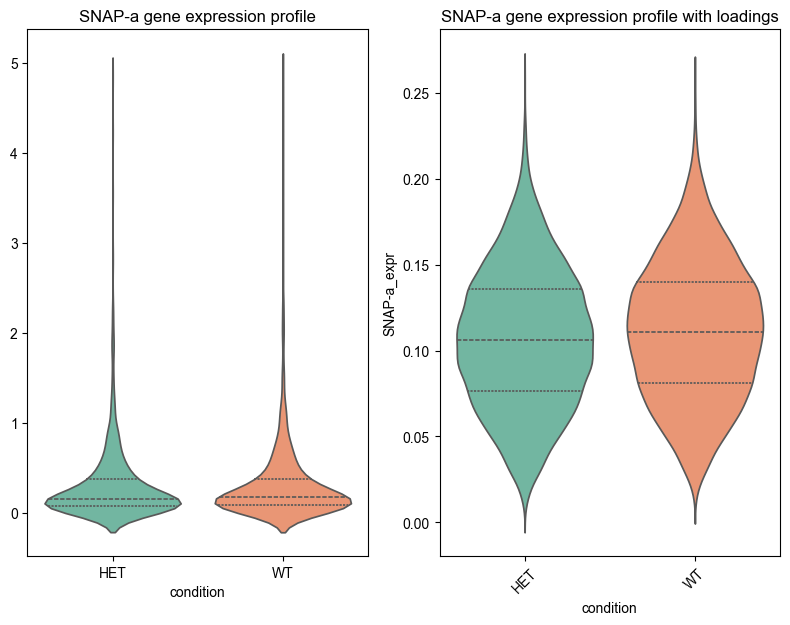

In [28]:
# modify the gene expression profile with SNAP-a loadings
# expr (cell by gene) * SNAP-a loadings (gene by 1)
plot_field = 'SNAP-a'

expr = pd.DataFrame(sdata.layers['log2_norm1e4'].toarray(), index=sdata.obs_names, columns=sdata.var_names)
expr = expr.values @ sdata.var[f'{plot_field}_loading'].values.reshape(-1, 1)
# convert to dataframe
expr = pd.DataFrame(expr, index=sdata.obs_names, columns=[f'{plot_field}_expr'])
# expr
# # add condition
expr['condition'] = sdata.obs['condition']
expr['region_label'] = sdata.obs['region_label']
expr['level_3'] = sdata.obs['level_3']

# # plot
fig, axs = plt.subplots(figsize=(8, 6), ncols=2)
sns.violinplot(data=plot_df.T, palette='Set2', inner='quartile', ax=axs[0])
sns.violinplot(data=expr, x='condition', y=f'{plot_field}_expr', palette='Set2', inner='quartile', ax=axs[1])
# rotate x-axis labels
plt.tight_layout()
plt.xticks(rotation=45)
# add subtitle
axs[0].set_title(f'{plot_field} gene expression profile')
axs[1].set_title(f'{plot_field} gene expression profile with loadings')
plt.show()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AC_2-[Cspg5_Mfge8]_WT vs. AC_2-[Cspg5_Mfge8]_HET: t-test independent samples with Bonferroni correction, P_val:4.404e-04 t=3.797e+00
AC_1-[Slc6a11_Agt]_WT vs. AC_1-[Slc6a11_Agt]_HET: t-test independent samples with Bonferroni correction, P_val:4.342e-21 t=9.576e+00
AC_3-[Gfap_Aqp4]_WT vs. AC_3-[Gfap_Aqp4]_HET: t-test independent samples with Bonferroni correction, P_val:6.286e-05 t=4.259e+00


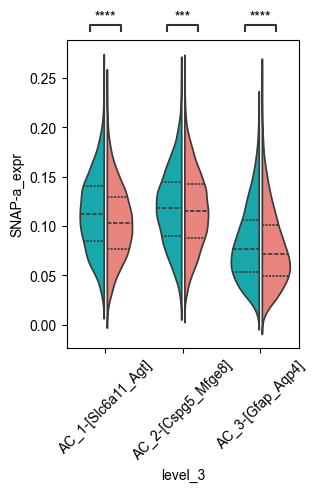

In [29]:
fig, ax = plt.subplots(figsize=(3, 4))
expr['condition'] = expr['condition'].astype('category').cat.reorder_categories(condition_order)


sns.violinplot(data=expr, x='level_3', y=f'{plot_field}_expr', hue='condition', palette=condition_pl, 
               legend=False, split=True, gap=.1, inner='quartile', ax=ax)
# rotate x-axis labels
plt.xticks(rotation=45)

# add statistical annotation 
from statannotations.Annotator import Annotator
annotator = Annotator(ax, pairs=[(('AC_1-[Slc6a11_Agt]', 'WT'), ('AC_1-[Slc6a11_Agt]', 'HET')),
                                 (('AC_2-[Cspg5_Mfge8]', 'WT'), ('AC_2-[Cspg5_Mfge8]', 'HET')),
                                 (('AC_3-[Gfap_Aqp4]', 'WT'), ('AC_3-[Gfap_Aqp4]', 'HET'))],
                      data=expr, x='level_3', y='SNAP-a_expr', hue='condition')
annotator.configure(test='t-test_ind', text_format='star', loc='outside', comparisons_correction='bonferroni', verbose=2)
annotator.apply_and_annotate()
plt.savefig(os.path.join(fig_path, 'SNAP-a_expr_violin_AC_level3_STAR.pdf'), bbox_inches='tight')

# from statannotations.Annotator import Annotator
# annotator = Annotator(ax, pairs=[(('TEGLU_L2/3-[Lamp5_Cux2]', 'WT'), ('TEGLU_L2/3-[Lamp5_Cux2]', 'HET')),
#                                  (('TEGLU_L4/5-[Rorb_Plcxd2]', 'WT'), ('TEGLU_L4/5-[Rorb_Plcxd2]', 'HET')),
#                                  (('TEGLU_L5/6-[C1ql3_Tox]', 'WT'), ('TEGLU_L5/6-[C1ql3_Tox]', 'HET')),
#                                  (('TEGLU_L6-[Pcp4_Hs3st4]', 'WT'), ('TEGLU_L6-[Pcp4_Hs3st4]', 'HET'))],
#                       data=expr, x='level_3', y=f'{plot_field}_expr', hue='condition')
# annotator.configure(test='t-test_ind', text_format='star', loc='outside', comparisons_correction='bonferroni', verbose=2)
# annotator.apply_and_annotate()
# plt.savefig(os.path.join(fig_path, f'{plot_field}_expr_violin_TEGLU_level3_STAR.pdf'), bbox_inches='tight')

plt.show()